# TVB Hybrid Simulation – Per-Subnetwork Integration Time Steps (multi-dt)

Every hybrid network so far integrated all subnetworks on one shared time
step.  With **multi-dt** each subnetwork keeps its *own* integration step:
a fast cortical population can run at 0.01 ms while a slow thalamic
population integrates at 0.04 ms, and the two remain causally consistent.

**What you'll learn**

- the **master clock**: all subnetwork dts must be integer multiples of the
  smallest one (`dt_j = k_j * dt0`), and the validation rule that enforces it;
- how a **fast target reading a slow source** is delayed/interpolated
  (fractional source-step reads with a zero-order-hold fallback), and how a
  slow target reading a fast source gets exact bracketing samples;
- that monitors, stimuli, RNG scaling and output **time axes all live on
  the master `dt0` grid**, whatever each subnetwork's own dt is;
- that the numba reference backend (`nb_hybrid`) and the compiled C++
  backend (`cpp_hybrid`) agree to tolerance on the same multi-dt network.

The semantics demonstrated here are the pinned specification in
`tvb_library/tvb/simulator/backend/cpp_hybrid/parity_audit.md` §6
("Multi-dt support"); both backends implement exactly those decisions.

In [1]:
import warnings
warnings.filterwarnings('ignore')   # suppress experimental-API warnings

import numpy as np
import scipy.sparse as sp
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

from tvb.simulator.models import MontbrioPazoRoxin, Linear
from tvb.simulator.integrators import HeunDeterministic
from tvb.simulator.monitors import Raw
from tvb.simulator.hybrid.network import NetworkSet
from tvb.simulator.hybrid.subnetwork import Subnetwork
from tvb.simulator.hybrid.inter_projection import InterProjection
from tvb.simulator.hybrid.coupling import Linear as LinearCfun
from tvb.simulator.hybrid.stimulus_utils import constant_stim
from tvb.simulator.backend.nb_hybrid import NbHybridBackend
from tvb.simulator.backend.cpp_hybrid.backend import CppHybridBackend

Running cmake --build in /home/duke/src/tvb-kh/tvb_library


## 1. A 2:1 network — fast cortex, slow thalamus

We build two `MontbrioPazoRoxin` subnetworks:

- **cortex**: `dt = 0.01` ms → `k = 1`, integrates on *every* master tick;
- **thalamus**: `dt = 0.02` ms → `k = 2`, integrates on *every second*
  master tick.

The master clock is `dt0 = min(dt_j) = 0.01` ms.  Delays on each
projection are expressed in **source steps** (`idelays`), exactly as in the
single-dt API — nothing about projection construction changes.

In [2]:
DT0 = 0.01          # master dt (the smallest subnet dt)
DT_A = 0.01         # cortex:  k = 1
DT_B = 0.02         # thalamus: k = 2

def mpr_subnet(name, dt, nnodes):
    model = MontbrioPazoRoxin()
    model.configure()
    sn = Subnetwork(name=name, model=model,
                    scheme=HeunDeterministic(dt=dt), nnodes=nnodes)
    sn.configure()
    return sn

def projection(src, tgt, src_dt, delay_steps, scale, seed):
    """InterProjection with a uniform per-edge delay (in source steps)."""
    rng = np.random.RandomState(seed)
    n_src, n_tgt = src.nnodes, tgt.nnodes
    W = np.zeros((n_tgt, n_src), np.float32)
    for i in range(n_tgt):
        for j in range(n_src):
            if i != j and rng.rand() < 0.6:
                W[i, j] = rng.rand()
    return InterProjection(
        source=src, target=tgt,
        source_cvar=np.array([0], dtype=np.int_),
        target_cvar=np.array([0], dtype=np.int_),
        weights=sp.csr_matrix(W),
        lengths=sp.csr_matrix((W != 0) * float(delay_steps * src_dt)),
        cfun=LinearCfun(),
        scale=scale, cv=1.0, dt=src_dt,
    )

cortex = mpr_subnet("cortex", DT_A, 5)
thalamus = mpr_subnet("thalamus", DT_B, 5)
projections = [
    projection(cortex, thalamus, DT_A, delay_steps=1, scale=0.02, seed=7),
    projection(thalamus, cortex, DT_B, delay_steps=1, scale=0.02, seed=11),
]
ns = NetworkSet(subnets=[cortex, thalamus], projections=projections)
ns.configure()

print("master dt0 =", DT0)
for sn in ns.subnets:
    k = round(sn.scheme.dt / DT0)
    print(f"  {sn.name:9s}: dt = {sn.scheme.dt:.3f} ms  "
          f"-> k = {k} (integrates every {k} master tick"
          f"{'s' if k > 1 else ''})")

master dt0 = 0.01
  cortex   : dt = 0.010 ms  -> k = 1 (integrates every 1 master tick)
  thalamus : dt = 0.020 ms  -> k = 2 (integrates every 2 master ticks)


### 1.1 The integer-multiple rule

A subnetwork dt must be an **integer multiple of `dt0`** — the master clock
ticks at `dt0`, and subnet `j` advances exactly one of its own (larger)
steps every `k_j` ticks.  A dt like `1.5 * dt0` cannot be scheduled on the
master grid and is rejected loudly by both backends:

In [3]:
from tvb.simulator.models import Generic2dOscillator

bad = mpr_subnet("bad", 1.5 * DT0, 3)            # 1.5 master ticks: invalid
ns_bad = NetworkSet(subnets=[cortex, bad], projections=[])
ns_bad.configure()
try:
    NbHybridBackend().compile(ns_bad)
except ValueError as exc:
    print("nb_hybrid rejected the network:")
    print(" ", exc)
try:
    CppHybridBackend().compile(ns_bad)
except ValueError as exc:
    print("cpp_hybrid rejected the network:")
    print(" ", exc)

nb_hybrid rejected the network:
  All subnetworks must use dts that are integer multiples of the smallest dt 0.01. Got dt=0.015 in 'bad' (1.5 master ticks, not an integer >= 1).
cpp_hybrid rejected the network:
  All subnetworks must use dts that are integer multiples of the smallest dt 0.01. Got dt=0.015 in 'bad' (1.5 master ticks, not an integer >= 1).


## 2. Run it: both backends, one trajectory

Both backends run the same network; the numba backend is the reference
implementation, the C++ backend must match it.  Output time axes are
master-grid times `t * dt0` (one sample per master tick at
`chunk_size=1`), regardless of each subnet's own dt.

In [4]:
NSTEP = 1500

nb_out = NbHybridBackend().compile(ns, eager=True).run(NSTEP)
cpp_out = CppHybridBackend().compile(ns).run(NSTEP)

t_nb, d_nb, c_nb = nb_out[0]
t_cp, d_cp, c_cp = cpp_out[0]
print("times identical:", np.array_equal(t_nb, t_cp))
print("max |data diff| :", np.abs(np.asarray(d_nb) - np.asarray(d_cp)).max())

times identical: True
max |data diff| : 1.1920929e-07


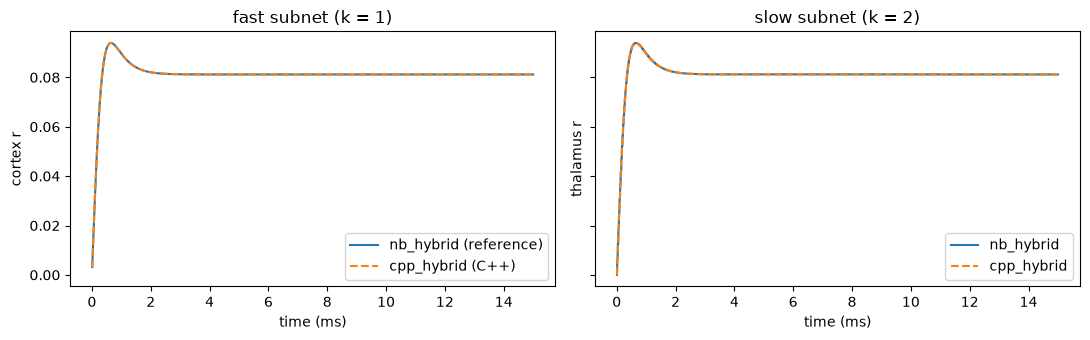

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
d_nb_arr = np.asarray(d_nb)[:, 0, :, :]     # (T, n_voi, nodes, modes)
d_cp_arr = np.asarray(d_cp)[:, 0, :, :]
axes[0].plot(t_nb, d_nb_arr[:, 0, 0], label="nb_hybrid (reference)")
axes[0].plot(t_cp, d_cp_arr[:, 0, 0], "--", label="cpp_hybrid (C++)")
axes[0].set_xlabel("time (ms)"); axes[0].set_ylabel("cortex r")
axes[0].set_title("fast subnet (k = 1)"); axes[0].legend()
axes[1].plot(t_nb, np.asarray(nb_out[1][1])[:, 0, 0, 0], label="nb_hybrid")
axes[1].plot(t_cp, np.asarray(cpp_out[1][1])[:, 0, 0, 0], "--", label="cpp_hybrid")
axes[1].set_xlabel("time (ms)"); axes[1].set_ylabel("thalamus r")
axes[1].set_title("slow subnet (k = 2)"); axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Read semantics: what a target sees when the dts differ

Coupling reads are expressed in **source steps**.  At master tick `t` the
read position of an inter-subnet projection is

`tau = (t - 1) / k_src - idelay`   (in source steps)

— the source state at the master time of the *start* of the target's step,
minus the delay.  The two bracketing pushed source samples `floor(tau)`
and `floor(tau) + 1` are blended with `alpha = frac(tau)`:

- a **fast target reading a slow source** (small `k_tgt`, large `k_src`)
  gets the *interpolated* source trajectory when `idelay >= 1`, and a
  zero-order hold (the newest pushed sample, held flat between source
  pushes) when `idelay == 0` — the spec never reads a not-yet-pushed
  sample and never extrapolates;
- a **slow target reading a fast source** reads exact, already-pushed
  samples (aligned reads);
- before the first delayed sample arrives the initial-condition-prefilled
  history ring supplies the IC (no zero-padding).

The cleanest way to *see* this is a linear ramp: a slow `Linear` source
(`gamma = 0`) driven by a constant stimulus of amplitude 1 rises exactly
as `x(time) = time`, so the coupling into an unforced fast target must be
the ramp sampled at the pinned read position — **exactly** for
`idelay >= 1` (linear interpolation is exact), and as a **staircase**
(zero-order hold) for `idelay == 0`.

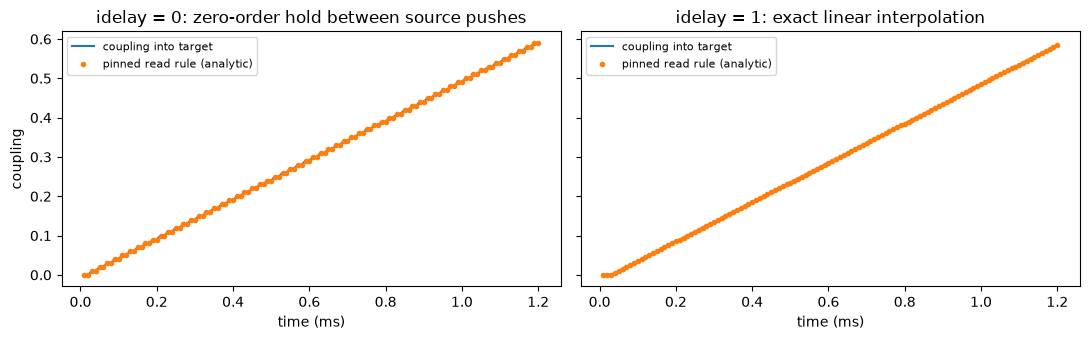

idelay = 0: max |coupling - analytic| = 1.454e-07
idelay = 1: max |coupling - analytic| = 1.407e-07


In [6]:
def ramp_net(dt_src, dt_tgt, delay_steps, scale=0.5):
    src = Subnetwork(name="ramp_src", model=Linear(),
                     scheme=HeunDeterministic(dt=dt_src), nnodes=2)
    src.model.gamma = np.array([0.0])
    src.model.configure()
    stim = constant_stim(src, amplitude=1.0, target_node=0,
                         target_cvar=0, simulation_length=10.0)
    src.stimuli = [stim]
    src.configure()
    tgt = Subnetwork(name="ramp_tgt", model=Linear(),
                     scheme=HeunDeterministic(dt=dt_tgt), nnodes=1)
    tgt.model.gamma = np.array([0.0])
    tgt.model.configure()
    tgt.configure()
    W = np.zeros((1, 2), np.float32); W[0, 0] = 1.0
    proj = InterProjection(
        source=src, target=tgt,
        source_cvar=np.array([0], dtype=np.int_),
        target_cvar=np.array([0], dtype=np.int_),
        weights=sp.csr_matrix(W),
        lengths=sp.csr_matrix((W != 0) * float(delay_steps * dt_src)),
        cfun=LinearCfun(), scale=scale, cv=1.0, dt=dt_src,
    )
    net = NetworkSet(subnets=[src, tgt], projections=[proj])
    net.configure()
    return net, scale

def analytic_ramp(dt_src, delay_steps, scale, nstep, dt0):
    """The pinned read rule, closed-form for the linear ramp."""
    k = max(1, round(dt_src / dt0))
    out = []
    for t in range(1, nstep + 1):
        tau = (t - 1) / k - delay_steps      # read position (source steps)
        if tau < 0:            # before the first sample: the IC (0)
            val = 0.0
        elif delay_steps == 0: # zero delay: zero-order hold of floor(tau)
            val = np.floor(tau) * dt_src
        else:                  # delay >= 1: interpolation is exact
            val = tau * dt_src
        out.append(scale * val)
    return np.asarray(out)

nstep = 120
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, delay_steps, title in (
        (axes[0], 0, "idelay = 0: zero-order hold between source pushes"),
        (axes[1], 1, "idelay = 1: exact linear interpolation")):
    net, sc = ramp_net(0.02, 0.01, delay_steps, scale=0.5)
    out = CppHybridBackend().compile(net).run(nstep)
    got = np.asarray(out[1][2])[:, 0, 0, 0]     # target ctavg (the coupling)
    expected = analytic_ramp(0.02, delay_steps, sc, nstep, 0.01)
    ax.plot(np.arange(1, nstep + 1) * 0.01, got, label="coupling into target")
    ax.plot(np.arange(1, nstep + 1) * 0.01, expected, "o", ms=3,
            label="pinned read rule (analytic)")
    ax.set_title(title)
    ax.set_xlabel("time (ms)"); ax.legend(fontsize=8)
axes[0].set_ylabel("coupling")
plt.tight_layout()
plt.show()

# numeric check: the zero-delay staircase and the delayed interpolation
# both match the pinned read rule to float32 round-off
for delay_steps in (0, 1):
    net, sc = ramp_net(0.02, 0.01, delay_steps, scale=0.5)
    got = np.asarray(CppHybridBackend().compile(net).run(nstep)[1][2])[:, 0, 0, 0]
    expected = analytic_ramp(0.02, delay_steps, sc, nstep, 0.01)
    print(f"idelay = {delay_steps}: max |coupling - analytic| = "
          f"{np.abs(got - expected).max():.3e}")

## 4. Monitors live on the master grid

Every monitor samples the **master** `dt0` grid: `istep = round(period /
dt0)` master ticks, and a slow subnet's recorded state simply *holds*
between its own integration steps (a zero-order hold of the state
trajectory — the samples remain meaningful master-grid observations).
A `Raw` monitor at `chunk_size = 1` makes the hold visible:

19 of 39 consecutive sample pairs are identical (the k=2 subnet holds on every off-tick)


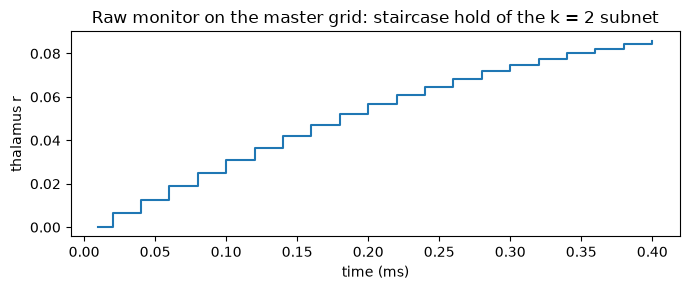

In [7]:
raw_out = CppHybridBackend().compile(ns).run(
    40, chunk_size=1, monitors=[Raw()])

per_subnet = raw_out[0]          # one entry per monitor
t_raw, d_raw = per_subnet[1]     # the slow (thalamus) subnet
d_raw = np.asarray(d_raw)[:, 0, 0, 0]     # (T,) one node's r

held = np.sum(np.abs(np.diff(d_raw)) < 1e-12)
print(f"{held} of {len(d_raw) - 1} consecutive sample pairs are identical "
      f"(the k=2 subnet holds on every off-tick)")

fig, ax = plt.subplots(figsize=(7, 3))
ax.step(t_raw, d_raw, where="post")
ax.set_xlabel("time (ms)"); ax.set_ylabel("thalamus r")
ax.set_title("Raw monitor on the master grid: staircase hold of the k = 2 subnet")
plt.tight_layout()
plt.show()

## 5. Summary

- **Master clock**: `dt0 = min(dt_j)`; subnet `j` integrates its own step
  `dt_j = k_j * dt0` on master ticks with `t % k_j == 0`.  Non-integer
  multiples are rejected at compile time.
- **Coupling reads** use the pinned position `tau = (t-1)/k_src - idelay`
  in source steps: interpolated bracketing samples when `idelay >= 1`,
  zero-order hold of the newest pushed sample when `idelay = 0`, IC-prefilled
  ring before the first delayed sample arrives.  Intra-subnet projections
  keep exact integer reads.
- **Monitors, stimuli, output time axes** are all master-grid quantities;
  a slow subnet's raw trace holds between its own steps.
- **Stochastic noise** is scaled by each subnet's *own* dt
  (`sqrt(2 * nsig * dt_j)`), and **merged (connectome-ordered) output**
  requires all merged subnetworks to share the same dt.
- The **kernel caches** (numba disk/in-process and the C++ topology key)
  include the dt vector, so changing any dt recompiles.

The full pinned specification — including the RNG draw order, resume /
snapshot semantics and the cache-key contract — is
`tvb_library/tvb/simulator/backend/cpp_hybrid/parity_audit.md` §6, and the
parity tests live in
`tvb_library/tvb/tests/library/simulator/backend/test_cpp_hybrid_multi_dt.py`.